In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-talk')

## Warteschlangenmodell MGc

![](Formeln.png) ![](Attribute.png)

In [2]:
def queue_mgc_coop(mean_wartezeit, server, mu, ladezeit, vk, wq_mgc=50, roh_0 = 0.99):
    # After Coop 1990 - S.508 - Formel 9.3
    lambda_0 = roh_0*(server*mu)
        
    while (wq_mgc > mean_wartezeit/60):
        lambda_0 -= 0.0001
        roh = lambda_0/(server*mu)
        wq = (roh/(1-roh))*(ladezeit/server)
        wq_mgc = wq*((1+vk**2)/2)
        wz_az = wq_mgc/ladezeit
    
    return [lambda_0, roh, wq*60, wq_mgc*60, wz_az]

In [3]:
def queue_mgc_Adan_Resing(mean_wartezeit, server, mu, ladezeit, vk, wq_mgc=50, roh_0 = 0.99):
   # Adan_Resing
    lambda_0 = roh_0*(server*mu)
        
    while (wq_mgc > mean_wartezeit/60):
            lambda_0 -= 0.0001
            
            roh = lambda_0/(server*mu)
            
            if server > 1:
                wq_part1 = (1/(1-roh))*(1/(server*mu))*(((server*roh)**server)/math.factorial(server))
                wq_part2 = (1-roh)*sum([(((server*roh)**n)/math.factorial(n) + ((server*roh)**server)/math.factorial(server)) for n in range(0, server-1)])
                wq = wq_part1 * wq_part2**-1
                
            else:
                wq = (roh/(1-roh))*(ladezeit/server)
                
            wq_mgc = wq*((1+vk**2)/2)
            wz_az = wq_mgc/ladezeit
    
    return [lambda_0, roh, wq*60, wq_mgc*60, wz_az]

In [4]:
def que_mgc(ladezeit, stdabw_lz, mean_wartezeit, max_server, method):
    
    dict_method = {'coop': queue_mgc_coop, 'adan' : queue_mgc_Adan_Resing} 
    method = dict_method[method]
    
    ladezeit = ladezeit/60
    stdabw_lz = stdabw_lz/60
    mu = 1/ladezeit
    vk = stdabw_lz/ladezeit
    
    queue = pd.DataFrame(0, index=list(range(1, max_server+1)), columns=['servers', 'lambda', 'roh', 'wq', 'wq_mgc', 'wz/az'])

    for server in range(1, max_server+1):
        
        queue.loc[server,['servers', 'lambda', 'roh', 'wq', 'wq_mgc', 'wz/az']] = [server] + method(mean_wartezeit, server, mu, ladezeit, vk)
    
    return queue

In [5]:
def que_mgc_server_wq(lambda_target, ladezeit, stdabw_lz, wartezeiten, method, max_server=1000):
    
    dict_method = {'coop': queue_mgc_coop, 'adan' : queue_mgc_Adan_Resing} 
    method = dict_method[method]
    
    dict_server_wq = {}
    
    ladezeit = ladezeit/60
    stdabw_lz = stdabw_lz/60
    mu = 1/ladezeit
    vk = stdabw_lz/ladezeit
    server = 0
    
    for mean_wartezeit in wartezeiten:
        
        for server in range(1, max_server+1):
            
            lambda_0, roh, wq, wq_mgc, wz_az = method(mean_wartezeit, server, mu, ladezeit, vk)
            
            if lambda_0 > lambda_target:
                break
        
        dict_server_wq[str(mean_wartezeit)] = server
        
    return lambda_target, dict_server_wq

In [6]:
def queue_wq_roh_coop(roh_range, server, ladezeit, stdabw_lz):
    
    queue = pd.DataFrame(columns=['lambda', 'server', 'roh', 'wq', 'wq_mgc', 'wz/az', 'krit_wert'])
    
    ladezeit = ladezeit/60
    stdabw_lz = stdabw_lz/60
    mu = 1/ladezeit
    vk = stdabw_lz/ladezeit
    
    for roh in roh_range:
        lambda_value = roh * (server*mu)
        
        if roh < 1:
            wq = (roh/(1-roh))*(ladezeit/server)
            wq_mgc = wq*((1+vk**2)/2)
            wz_az = wq_mgc/ladezeit
        else:
            break
        
        queue.loc[lambda_value,['lambda', 'server', 'roh', 'wq', 'wq_mgc', 'wz/az', 'krit_wert']] = lambda_value, server, roh, wq*60, wq_mgc*60, wz_az,  lambda_value/server
    
    return queue.astype('float')

In [25]:
lambda_target = 5
waiting_times = [5, 10, 15, 20]


que_mgc_server_wq(lambda_target, 45, 10, waiting_times, 'coop') #(lambda_target, ladezeit, stdabw_lz, wartezeiten, method, max_server=1000):

(5, {'5': 7, '10': 6, '15': 5, '20': 5})

In [11]:
queue_25_adan = que_mgc(25, 10, 5, 32,'adan') #que_mgc(ladezeit, stdabw_lz, mean_wartezeit, max_server, method)

In [12]:
queue_25_adan.to_csv('warteschlange_adan_25_10_5_32.csv') 

In [13]:
queue_25 = que_mgc(25, 10, 5, 32,'coop')

In [14]:
queue_25.to_csv('warteschlange_coop_25_10_5_32.csv')

In [21]:
roh_range = np.arange(0, 0.999, 0.002)
ladezeit = 25
#queue_wq_lambda_coop(lambda_max, server, ladezeit, stdabw_lz)
queue_2_server = queue_wq_roh_coop(roh_range, 2, ladezeit, 10)
queue_4_server = queue_wq_roh_coop(roh_range, 4, ladezeit, 10)
queue_8_server = queue_wq_roh_coop(roh_range, 8, ladezeit, 10)
queue_10_server = queue_wq_roh_coop(roh_range, 10, ladezeit, 10)
queue_15_server = queue_wq_roh_coop(roh_range, 15, ladezeit, 10)
queue_20_server = queue_wq_roh_coop(roh_range, 20, ladezeit, 10)

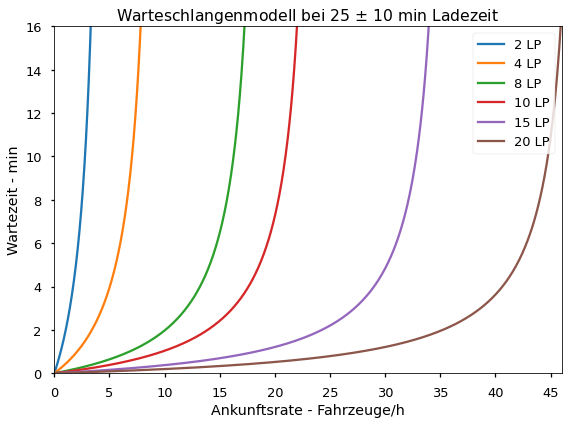

In [22]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='lambda', y='wq_mgc', data=queue_2_server, ax=ax, label='2 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_4_server, ax=ax, label='4 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_8_server, ax=ax, label='8 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_10_server, ax=ax, label='10 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_15_server, ax=ax, label='15 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_20_server, ax=ax, label='20 LP')
plt.ylim(0, 16)
plt.xlim(0, 46)
plt.xticks(np.arange(0, 46, 5))
#plt.yscale('log')
plt.xlabel('Ankunftsrate - Fahrzeuge/h')
plt.ylabel('Wartezeit - min')
plt.title(f'Warteschlangenmodell bei {ladezeit} $\pm$ 10 min Ladezeit')
plt.legend()
plt.tight_layout()
plt.savefig(f'figs/warte_{ladezeit}_ankunft_vs_zeit.jpg')
plt.show()

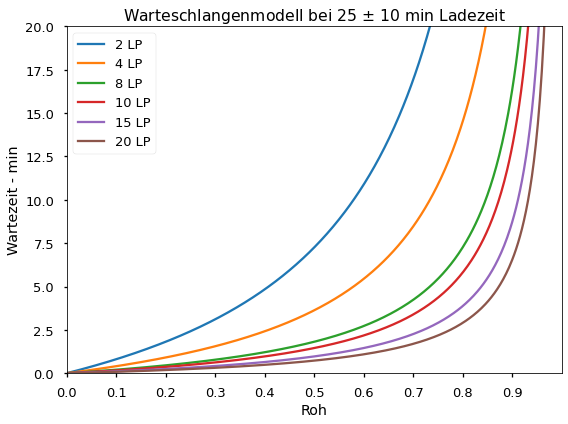

In [23]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='roh', y='wq_mgc', data=queue_2_server, ax=ax, label='2 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_4_server, ax=ax, label='4 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_8_server, ax=ax, label='8 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_10_server, ax=ax, label='10 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_15_server, ax=ax, label='15 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_20_server, ax=ax, label='20 LP')
plt.ylim(0, 20)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1, 0.1))
#plt.yscale('log')
plt.xlabel('Roh')
plt.ylabel('Wartezeit - min')
plt.title(f'Warteschlangenmodell bei {ladezeit} $\pm$ 10 min Ladezeit')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
queue_20_server[(queue_20_server['roh'] > 0.75) & (queue_20_server['roh'] < 0.85)]

,lambda,server,roh,wq,wq_mgc,wz/az,krit_wert
36.096,36.096,20.0,0.752,3.790323,2.198387,0.087935,1.8048
36.192,36.192,20.0,0.754,3.831301,2.222154,0.088886,1.8096
36.288,36.288,20.0,0.756,3.872951,2.246311,0.089852,1.8144
36.384,36.384,20.0,0.758,3.915289,2.270868,0.090835,1.8192
36.480,36.480,20.0,0.760,3.958333,2.295833,0.091833,1.8240
36.576,36.576,20.0,0.762,4.002101,2.321218,0.092849,1.8288
36.672,36.672,20.0,0.764,4.046610,2.347034,0.093881,1.8336
36.768,36.768,20.0,0.766,4.091880,2.373291,0.094932,1.8384
36.864,36.864,20.0,0.768,4.137931,2.400000,0.096000,1.8432
36.960,36.960,20.0,0.770,4.184783,2.427174,0.097087,1.8480


In [29]:
ladezeit_que = 25
queue_warte_1 = que_mgc(ladezeit_que, 10, 1, 32,'coop')
queue_warte_2 = que_mgc(ladezeit_que, 10, 2, 32,'coop')
queue_warte_5 = que_mgc(ladezeit_que, 10, 5, 32,'coop')
queue_warte_10 = que_mgc(ladezeit_que, 10, 10, 32,'coop')
queue_warte_15 = que_mgc(ladezeit_que, 10, 15, 32,'coop')

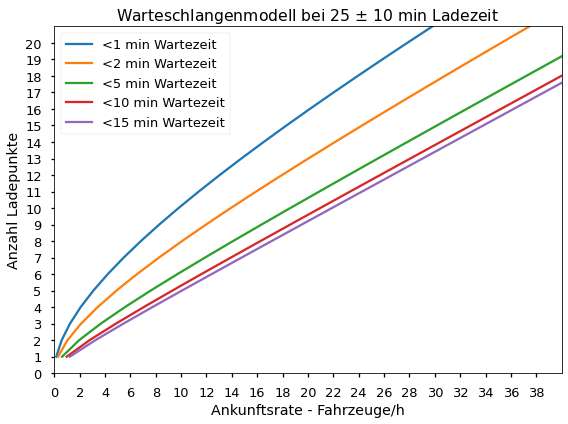

In [30]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='lambda', y='servers', data=queue_warte_1, ax=ax, label='<1 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_2, ax=ax, label='<2 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_5, ax=ax, label='<5 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_10, ax=ax, label='<10 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_15, ax=ax, label='<15 min Wartezeit')
plt.ylim(0, 21)
plt.xlim(0, 40)
plt.xticks(np.arange(0, 40, 2))
plt.yticks(np.arange(0, 21, 1))
plt.ylabel('Anzahl Ladepunkte')
plt.xlabel('Ankunftsrate - Fahrzeuge/h')
plt.legend()
plt.title(f'Warteschlangenmodell bei {ladezeit_que} $\pm$ 10 min Ladezeit')
plt.tight_layout()
plt.savefig(f'figs/warte_{ladezeit_que}_ankunft_vs_ladepunkte.jpg')
plt.show()

In [18]:
queue_warte_5

,servers,lambda,roh,wq,wq_mgc,wz/az
1,1,0.2330,0.174750,9.528931,4.999748,0.111106
2,2,0.7933,0.297487,9.527900,4.999207,0.111093
3,3,1.5539,0.388475,9.528842,4.999701,0.111104
4,4,2.4458,0.458587,9.528981,4.999774,0.111106
5,5,3.4285,0.514275,9.529003,4.999786,0.111106
6,6,4.4766,0.559575,9.529006,4.999787,0.111106
7,7,5.5734,0.597150,9.529158,4.999867,0.111108
8,8,6.7074,0.628819,9.529322,4.999953,0.111110
9,9,7.8704,0.655867,9.529252,4.999916,0.111109
10,10,9.0566,0.679245,9.529399,4.999994,0.111111


In [105]:
queue_5_server[queue_5_server['wq_mgc'] < 5]

,lambda,server,roh,wq,wq_mgc,wz/az,krit_wert
0.00,0.00,5.0,0.000,0.000000,0.000000,0.000000,0.000
0.02,0.02,5.0,0.002,0.012024,0.006680,0.000223,0.004
0.04,0.04,5.0,0.004,0.024096,0.013387,0.000446,0.008
0.06,0.06,5.0,0.006,0.036217,0.020121,0.000671,0.012
0.08,0.08,5.0,0.008,0.048387,0.026882,0.000896,0.016
...,...,...,...,...,...,...,...
5.90,5.90,5.0,0.590,8.634146,4.796748,0.159892,1.180
5.92,5.92,5.0,0.592,8.705882,4.836601,0.161220,1.184
5.94,5.94,5.0,0.594,8.778325,4.876847,0.162562,1.188
5.96,5.96,5.0,0.596,8.851485,4.917492,0.163916,1.192
